In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [74]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv')

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df['child'] = df['Age']<= 16

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
child            0
dtype: int64

In [6]:
a = {'A': [1,2,3,5],
    'B':[34,55,33,5],
    'C': [67, 32,11,23]}
b = {'D': [2,5,6,7],
    'E': [12,27,30,5],
    'F':[4,15,33,5],
    'C': [17, 72,11,23]}

In [7]:
df1 = pd.DataFrame(a)

In [8]:
df2 = pd.DataFrame(b)

In [9]:
df1

,A,B,C
0,1,34,67
1,2,55,32
2,3,33,11
3,5,5,23


In [10]:
df3 = df[['Name','Age','Sex']][0:5]

In [11]:
df3.reset_index(drop = True, inplace = True)

In [12]:
df4 = df[['Survived','Pclass']][5:10]

df4

In [13]:
pd.concat([df3, df4], axis = 1)

,Name,Age,Sex,Survived,Pclass
0,"Braund, Mr. Owen Harris",22.0,male,NaN,NaN
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female,NaN,NaN
2,"Heikkinen, Miss. Laina",26.0,female,NaN,NaN
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,NaN,NaN
4,"Allen, Mr. William Henry",35.0,male,NaN,NaN
5,NaN,NaN,NaN,0.0,3.0
6,NaN,NaN,NaN,0.0,1.0
7,NaN,NaN,NaN,0.0,3.0
8,NaN,NaN,NaN,1.0,3.0
9,NaN,NaN,NaN,1.0,2.0


In [14]:
z= np.random.rand(5,5)

In [15]:
x= pd.DataFrame(z, index = ('a','b',"c",'d','e'))

In [16]:
np.mean(df['Age'])

np.float64(29.69911764705882)

In [17]:
df3

,Name,Age,Sex
0,"Braund, Mr. Owen Harris",22.0,male
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female
2,"Heikkinen, Miss. Laina",26.0,female
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female
4,"Allen, Mr. William Henry",35.0,male


In [18]:
df4

,Survived,Pclass
5,0,3
6,0,1
7,0,3
8,1,3
9,1,2


In [19]:
df3.merge(df4, how = 'outer', left_on = 'Age', right_on ='Pclass')

,Name,Age,Sex,Survived,Pclass
0,NaN,NaN,NaN,0.0,1.0
1,NaN,NaN,NaN,1.0,2.0
2,NaN,NaN,NaN,0.0,3.0
3,NaN,NaN,NaN,0.0,3.0
4,NaN,NaN,NaN,1.0,3.0
5,"Braund, Mr. Owen Harris",22.0,male,NaN,NaN
6,"Heikkinen, Miss. Laina",26.0,female,NaN,NaN
7,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,NaN,NaN
8,"Allen, Mr. William Henry",35.0,male,NaN,NaN
9,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female,NaN,NaN


In [20]:
df1

,A,B,C
0,1,34,67
1,2,55,32
2,3,33,11
3,5,5,23


In [21]:
df2

,D,E,F,C
0,2,12,4,17
1,5,27,15,72
2,6,30,33,11
3,7,5,5,23


In [22]:
df1.merge(df2, how = 'cross') # merge data all the combination of data row wise

,A,B,C_x,D,E,F,C_y
0,1,34,67,2,12,4,17
1,1,34,67,5,27,15,72
2,1,34,67,6,30,33,11
3,1,34,67,7,5,5,23
4,2,55,32,2,12,4,17
5,2,55,32,5,27,15,72
6,2,55,32,6,30,33,11
7,2,55,32,7,5,5,23
8,3,33,11,2,12,4,17
9,3,33,11,5,27,15,72


In [23]:
pd.merge(df1, df2, how = 'inner', left_on = 'A', right_on = 'D') # inner mergr of data base on df1 column A and df2 column D

,A,B,C_x,D,E,F,C_y
0,2,55,32,2,12,4,17
1,5,5,23,5,27,15,72


In [24]:
pd.merge(df1, df2, how = 'inner', on = 'C')# on use for merge the common column base 

,A,B,C,D,E,F
0,3,33,11,6,30,33
1,5,5,23,7,5,5


In [25]:
pd.merge(df1, df2, how = 'inner')

,A,B,C,D,E,F
0,3,33,11,6,30,33
1,5,5,23,7,5,5


In [26]:
pd.merge(df1, df2, how = 'left', left_on = 'A', right_on = 'D') # left mergr of data base on df1 column A and df2 column D

,A,B,C_x,D,E,F,C_y
0,1,34,67,NaN,NaN,NaN,NaN
1,2,55,32,2.0,12.0,4.0,17.0
2,3,33,11,NaN,NaN,NaN,NaN
3,5,5,23,5.0,27.0,15.0,72.0


In [27]:
pd.merge(df1, df2, how = 'right', left_on = 'A', right_on = 'D') # right mergr of data base on df1 column A and df2 column D

,A,B,C_x,D,E,F,C_y
0,2.0,55.0,32.0,2,12,4,17
1,5.0,5.0,23.0,5,27,15,72
2,NaN,NaN,NaN,6,30,33,11
3,NaN,NaN,NaN,7,5,5,23


In [28]:
pd.merge(df1, df2, how = 'outer', left_on = 'A', right_on = 'D') # outer mergr of data base on df1 column A and df2 column D

,A,B,C_x,D,E,F,C_y
0,1.0,34.0,67.0,NaN,NaN,NaN,NaN
1,2.0,55.0,32.0,2.0,12.0,4.0,17.0
2,3.0,33.0,11.0,NaN,NaN,NaN,NaN
3,5.0,5.0,23.0,5.0,27.0,15.0,72.0
4,NaN,NaN,NaN,6.0,30.0,33.0,11.0
5,NaN,NaN,NaN,7.0,5.0,5.0,23.0


In [29]:
def ad(x):
    return x *10

In [30]:
df['Age'].apply(ad)

0      220.0
1      380.0
2      260.0
3      350.0
4      350.0
       ...  
886    270.0
887    190.0
888      NaN
889    260.0
890    320.0
Name: Age, Length: 891, dtype: float64

In [31]:
def man_wom_chi(passenger):
    age=passenger['Age']
    sex=passenger['Sex']
    
    return 'child' if age < 16 else sex

In [32]:
df.drop('child', axis = 1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [33]:
df['child'] = df.apply(man_wom_chi, axis = 1)

In [34]:
## df['Age']= df['Age'].fillna(np.mean(df['Age']))

In [35]:
df['Person'] = df.apply(man_wom_chi,axis=1)

In [36]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,child,Person
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,male,male
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,female,female
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,female,female
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,male,male


In [37]:
df.drop('PassengerId', axis = 1 , inplace = True)

In [38]:
df.set_index('Name', inplace= True)

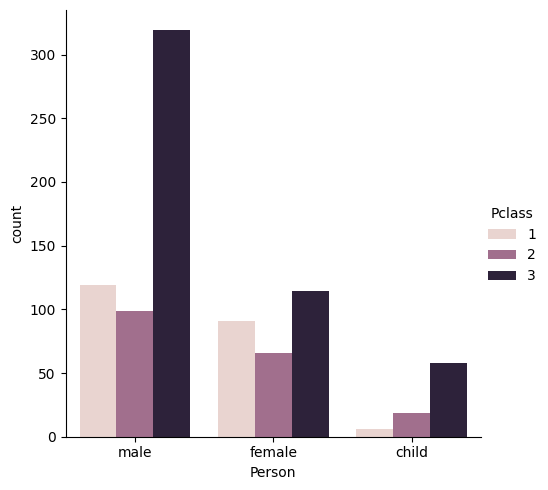

In [39]:
sns.catplot(df,x = 'Person', kind = 'count', hue = 'Pclass')

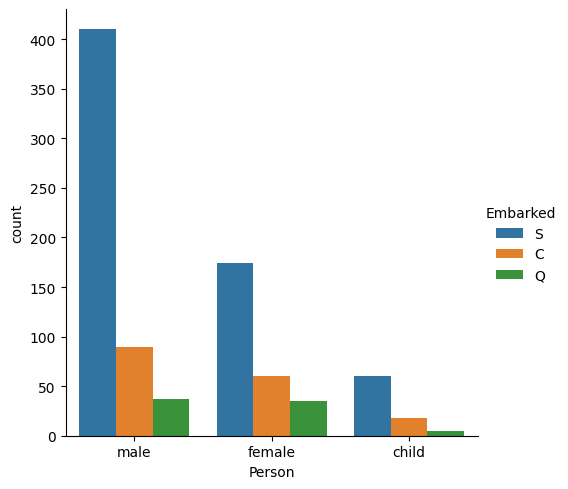

In [40]:
sns.catplot(df,x = 'Person', kind = 'count', hue = 'Embarked')

In [41]:
def whos_age(x):
    age = x['Age']
    sex = x['Sex']
    if age <= 10:
        return 'child under 10 year'
    elif x['Age'] >10 and x['Age'] <=17:
        return 'minor'
    elif x['Age'] >17 and x['Age'] <=35:
        return 'younger'
    elif x['Age'] >35:
        return sex

In [42]:
df['whos'] = df.apply(whos_age, axis = 1)

In [43]:
df.reset_index(inplace = True)

In [44]:
df['whos'].unique()

<StringArray>
['younger', 'female', nan, 'male', 'child under 10 year', 'minor']
Length: 6, dtype: str

In [45]:
df['whos'].info()

<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: whos
Non-Null Count  Dtype
--------------  -----
714 non-null    str  
dtypes: str(1)
memory usage: 7.1 KB


In [46]:
df.drop('child', axis = 1, inplace = True)

In [47]:
df

,Name,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,whos
0,"Braund, Mr. Owen Harris",0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,younger
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,female,female
2,"Heikkinen, Miss. Laina",1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,younger
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,female,35.0,1,0,113803,53.1000,C123,S,female,younger
4,"Allen, Mr. William Henry",0,3,male,35.0,0,0,373450,8.0500,NaN,S,male,younger
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,"Montvila, Rev. Juozas",0,2,male,27.0,0,0,211536,13.0000,NaN,S,male,younger
887,"Graham, Miss. Margaret Edith",1,1,female,19.0,0,0,112053,30.0000,B42,S,female,younger
888,"Johnston, Miss. Catherine Helen ""Carrie""",0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,female,NaN
889,"Behr, Mr. Karl Howell",1,1,male,26.0,0,0,111369,30.0000,C148,C,male,younger


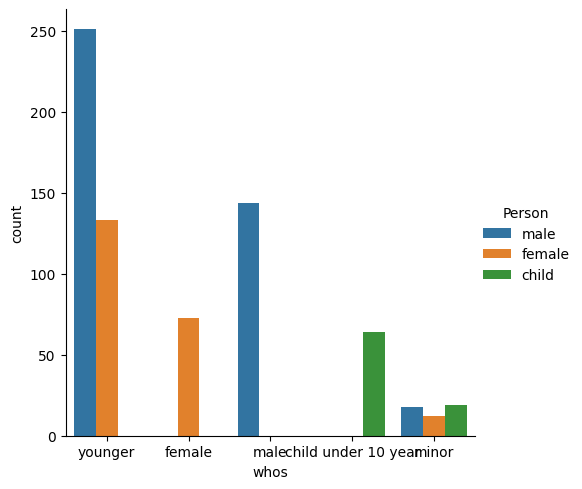

In [48]:
sns.catplot(df, x = 'whos', kind = 'count', hue = 'Person' )

In [49]:
df['Family_count'] = df['SibSp'] + df['Parch']

In [50]:
df

,Name,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,whos,Family_count
0,"Braund, Mr. Owen Harris",0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,younger,1
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,female,female,1
2,"Heikkinen, Miss. Laina",1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,younger,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,female,35.0,1,0,113803,53.1000,C123,S,female,younger,1
4,"Allen, Mr. William Henry",0,3,male,35.0,0,0,373450,8.0500,NaN,S,male,younger,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,"Montvila, Rev. Juozas",0,2,male,27.0,0,0,211536,13.0000,NaN,S,male,younger,0
887,"Graham, Miss. Margaret Edith",1,1,female,19.0,0,0,112053,30.0000,B42,S,female,younger,0
888,"Johnston, Miss. Catherine Helen ""Carrie""",0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,female,NaN,3
889,"Behr, Mr. Karl Howell",1,1,male,26.0,0,0,111369,30.0000,C148,C,male,younger,0


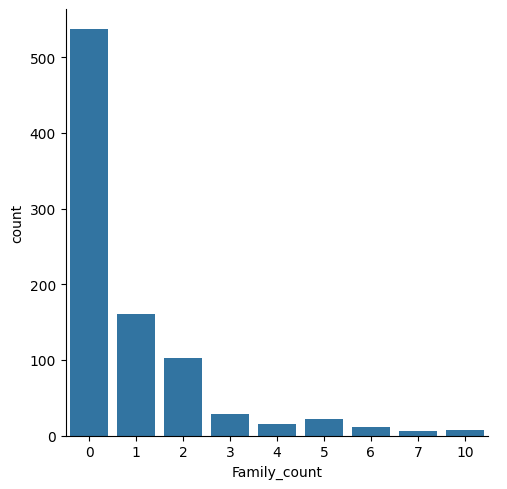

In [51]:
sns.catplot(df, x = 'Family_count', kind = 'count')

In [52]:
pd.set_option('display.max_colwidth',1000)

In [53]:
df

,Name,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,whos,Family_count
0,"Braund, Mr. Owen Harris",0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,younger,1
1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,female,female,1
2,"Heikkinen, Miss. Laina",1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,younger,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,female,35.0,1,0,113803,53.1000,C123,S,female,younger,1
4,"Allen, Mr. William Henry",0,3,male,35.0,0,0,373450,8.0500,NaN,S,male,younger,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,"Montvila, Rev. Juozas",0,2,male,27.0,0,0,211536,13.0000,NaN,S,male,younger,0
887,"Graham, Miss. Margaret Edith",1,1,female,19.0,0,0,112053,30.0000,B42,S,female,younger,0
888,"Johnston, Miss. Catherine Helen ""Carrie""",0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,female,NaN,3
889,"Behr, Mr. Karl Howell",1,1,male,26.0,0,0,111369,30.0000,C148,C,male,younger,0


In [54]:
import time 

In [55]:
strt = time.time()
for i in range(1000):
    pass
end = time.time()
print(end - strt)


0.00019168853759765625


In [56]:
x = np.random.randint(5, 500,50)
y = np.random.randn(50)

In [57]:
x1 = pd.DataFrame(x, columns = ['Data'], index = pd.date_range(start='2004-01-01', periods=50, freq = 'YE'))
y1 = pd.DataFrame(y, columns = ['Data'], index = pd.date_range(start='2004-01-01', periods=50, freq = 'YE'))

In [58]:
x1

,Data
2004-12-31,165
2005-12-31,419
2006-12-31,359
2007-12-31,398
2008-12-31,47
2009-12-31,325
2010-12-31,300
2011-12-31,102
2012-12-31,491
2013-12-31,87


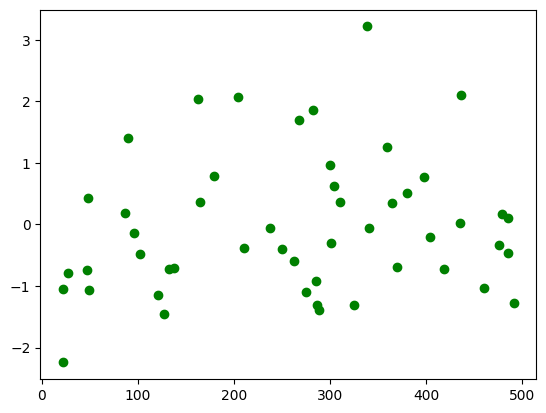

In [59]:
plt.scatter(x= x1, y= y1, color = 'g')

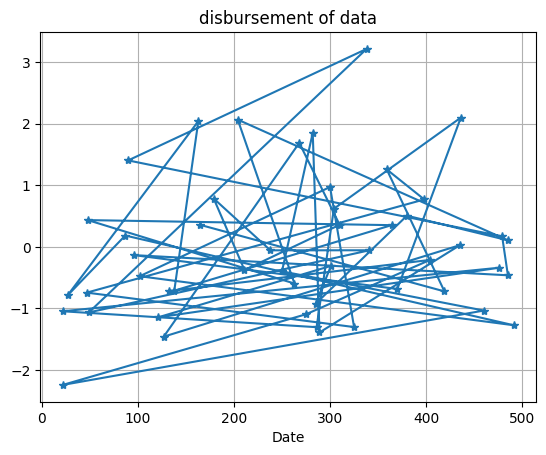

In [60]:
plt.plot(x1, y1, marker = '*')
plt.title('disbursement of data')
plt.xlabel('Date')
plt.grid()
plt.show()
#plt.plot(y1)

In [61]:
df

,Name,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,whos,Family_count
0,"Braund, Mr. Owen Harris",0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,younger,1
1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,female,female,1
2,"Heikkinen, Miss. Laina",1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,younger,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,female,35.0,1,0,113803,53.1000,C123,S,female,younger,1
4,"Allen, Mr. William Henry",0,3,male,35.0,0,0,373450,8.0500,NaN,S,male,younger,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,"Montvila, Rev. Juozas",0,2,male,27.0,0,0,211536,13.0000,NaN,S,male,younger,0
887,"Graham, Miss. Margaret Edith",1,1,female,19.0,0,0,112053,30.0000,B42,S,female,younger,0
888,"Johnston, Miss. Catherine Helen ""Carrie""",0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,female,NaN,3
889,"Behr, Mr. Karl Howell",1,1,male,26.0,0,0,111369,30.0000,C148,C,male,younger,0


<BarContainer object of 891 artists>

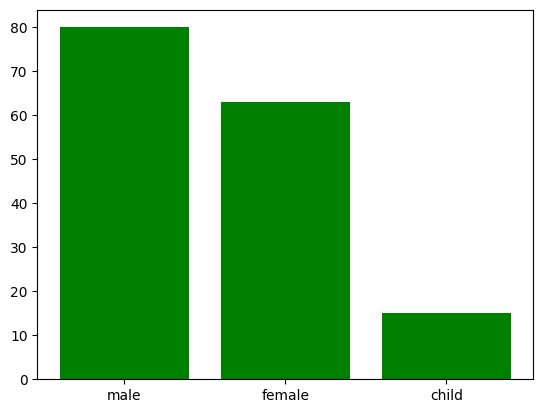

In [62]:
plt.bar( df['Person'],df['Age'], color = 'green')

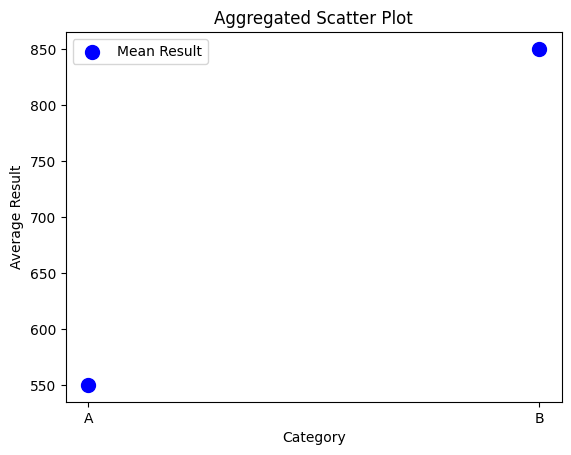

In [64]:

# Sample Data
data = {'Category': ['A', 'B', 'A', 'B', 'A', 'B'],
        'Values': [10, 15, 20, 25, 30, 35],
        'Result': [100, 200, 150, 250, 300, 400]}
df = pd.DataFrame(data)

# --- Aggregate Data using Pandas ---
# Group by 'Category' and calculate the mean for other columns
grouped_data = df.groupby('Category').sum().reset_index()

# --- Plot the Aggregated Data ---
plt.scatter(grouped_data['Category'], grouped_data['Result'], 
            s=100, color='blue', label='Mean Result')

plt.xlabel('Category')
plt.ylabel('Average Result')
plt.title('Aggregated Scatter Plot')
plt.legend()
plt.show()


C:\Users\tenja\AppData\Local\Temp\ipykernel_5904\2870839325.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


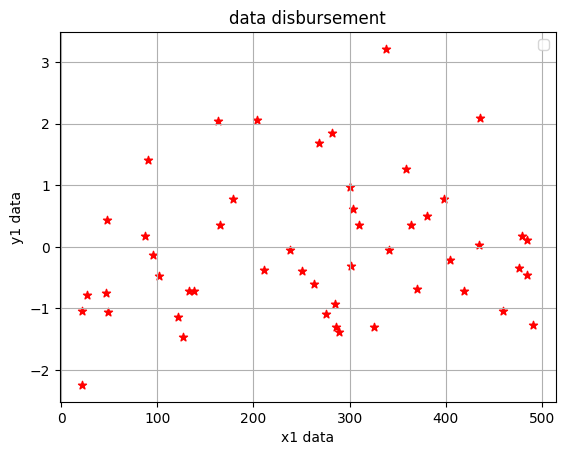

In [65]:
plt.scatter(x1, y1,marker = '*', color = 'r', )
plt.title('data disbursement')
plt.xlabel('x1 data')
plt.ylabel('y1 data')
plt.legend()
plt.grid()
plt.show()

In [66]:
df1 = sns.load_dataset('tips')

In [67]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


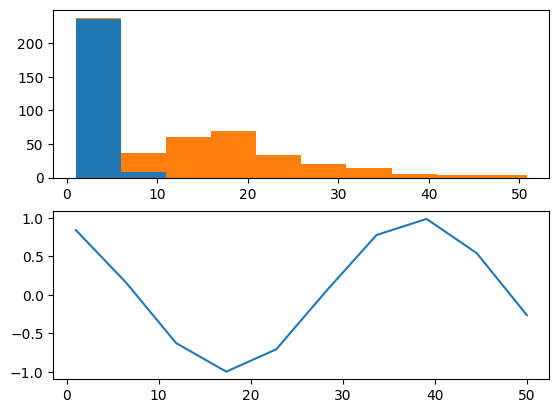

In [83]:
plt.subplot(2,1,1)
plt.hist([df1['tip'], df1['total_bill']], stacked=True, label=['Col 1', 'Col 2'] )


plt.subplot(2,1,2)
plt.plot(x, np.sin(x))
plt.show()

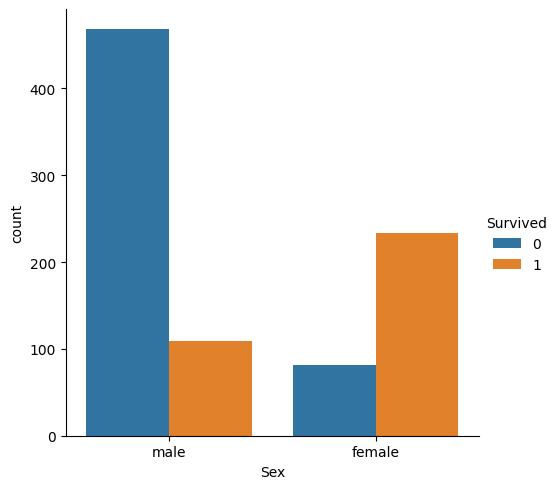

In [92]:
sns.catplot(df, x = 'Sex', kind = 'count' , hue= "Survived" )

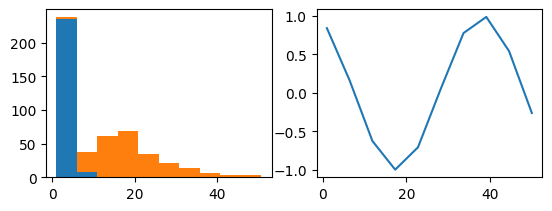

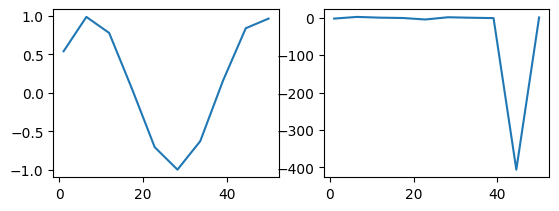

In [86]:
plt.subplot(2,2,1)
plt.hist([df1['tip'], df1['total_bill']], stacked=True, label=['Col 1', 'Col 2'] )


plt.subplot(2,2,2)
plt.plot(x, np.sin(x))
plt.show()

plt.subplot(2,2,3)
plt.plot(x, np.cos(x))

plt.subplot(2,2,4)
plt.plot(x, np.tan(x+1))
plt.show()

In [76]:
df[df["Age"] < df["Age"].mean()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


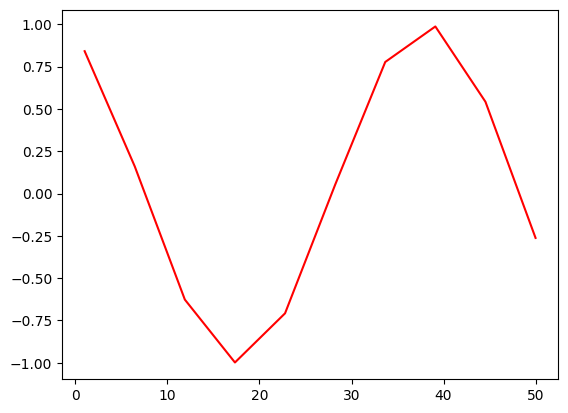

In [79]:
plt.plot(x , np.sin(x),color= 'r' )

In [78]:
x =  np.linspace(1, 50, 10)

In [75]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


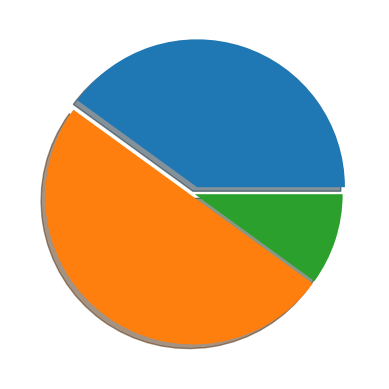

In [119]:
plt.pie(x = [40,50,10], shadow = True, explode = (0.05, 0.02, 0.0))
plt.show()

<BarContainer object of 891 artists>

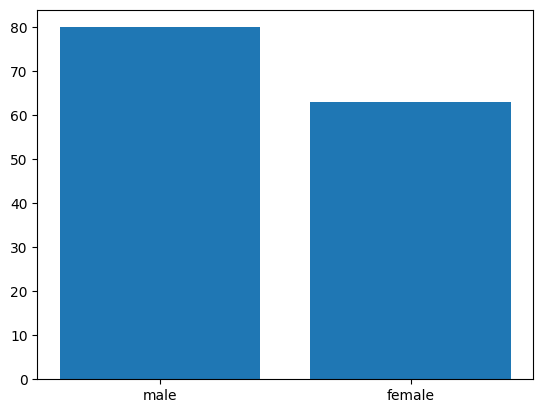

In [121]:
plt.bar(x = df['Sex'], height = df["Age"])